# Exploratory Data Analysis: Football Stadium Attendance Dataset

In this notebook we take `data/full_dataset_clean.csv` and perform exploratory data anaylsis for it. Our goal here is to find patterns, relationships, and understanding the dataset.

## 1. Descriptive Statistics for Attendance, Capacity, Attendance Percentage, Home and Away Team Pregame Elo, and temperature

The code below examines football stadium attendance using key variables such as attendance, stadium capacity, attendance percentage, home and away team pregame Elo ratings, and temperature. First, descriptive statistics are calculated to understand the distribution and variability of these variables, including their mean, standard deviation, minimum, maximum, and quartile values. A correlation analysis is then used to identify relationships between attendance and the other variables, helping determine which factors are most closely associated with attendance. Finally, the dataset is grouped by the home team's conference to calculate average attendance for each conference.

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df = pd.read_csv("../data/full_dataset_clean.csv")

key_cols = [
    "attendance",
    "capacity",
    "attendance_pct",
    "homePregameElo",
    "awayPregameElo",
    "temperature_c",
]
print("Summary Statistics:")
print(df[key_cols].describe().T)

corr = df[key_cols].corr()
print("\nCorrelation with Attendance")
print(corr["attendance"].sort_values(ascending=False))

avg_conf_pct = (
    df.groupby("homeConference")["attendance"]
    .mean()
    .sort_values(ascending=False)
)
print("\n--- Average Attendance by Conference ---")
print(avg_conf_pct)

Summary Statistics:
                 count          mean           std           min          25%  \
attendance      1735.0  42131.882421  26900.019956   1156.000000  20019.00000   
capacity        2017.0  50581.574120  24013.241291  11040.000000  30200.00000   
attendance_pct  1731.0      0.796516      0.230966      0.048167      0.62934   
homePregameElo  2021.0   1514.483548    234.549532    748.000000   1365.00000   
awayPregameElo  2021.0   1487.692691    213.235127    735.000000   1367.00000   
temperature_c   2021.0     21.347303      8.344927     -6.200000     16.40000   

                         50%           75%            max  
attendance      35782.000000  58591.500000  111373.000000  
capacity        47000.000000  65632.000000  107601.000000  
attendance_pct      0.861682      0.994729       2.149577  
homePregameElo   1510.000000   1645.000000    2196.000000  
awayPregameElo   1480.000000   1594.000000    2263.000000  
temperature_c      23.100000     27.300000      41.3

## 2. Visualize Relationships: Attendance vs. Capacity, Attendance vs Attendance Percentage, Attendance by Conference, Attendance vs. Temperature, Attendance vs. Stadium Capacity by Home Team Strength

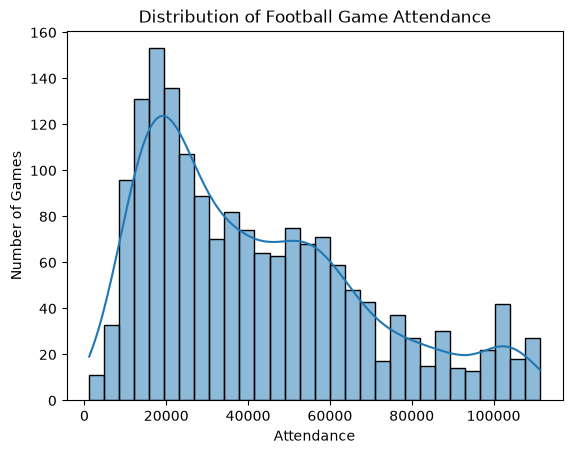

In [8]:
sns.histplot(data=df, x="attendance", bins=30, kde=True)
plt.title("Distribution of Football Game Attendance")
plt.xlabel("Attendance")
plt.ylabel("Number of Games")
plt.show()

The histogram shows the distribution of football game attendance in the dataset. Most games have attendance between approximately 10,000 and 30,000 spectators, with the highest concentration occurring around 15,000–20,000 attendees. As attendance increases beyond 30,000, the number of games generally decreases. A smaller number of games have very high attendance, reaching over 100,000 spectators. Overall, the distribution is right-skewed, meaning that most games have relatively lower attendance while a smaller number of games have exceptionally high attendance. The multiple peaks also suggest that attendance may vary substantially depending on factors such as stadium size, conference, team popularity, or game characteristics.

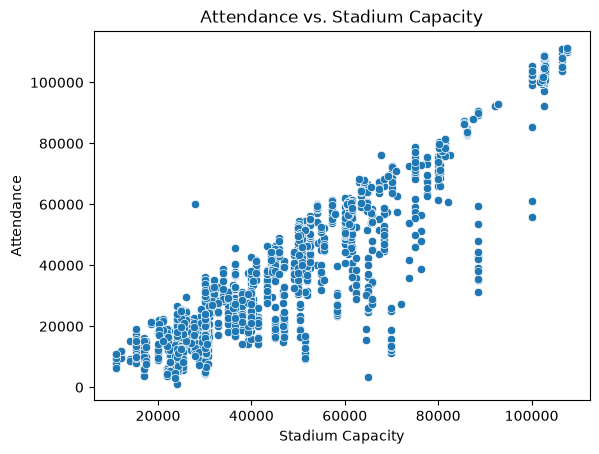

In [9]:
sns.scatterplot(data=df, x="capacity", y="attendance")
plt.title("Attendance vs. Stadium Capacity")
plt.xlabel("Stadium Capacity")
plt.ylabel("Attendance")
plt.show()

The scatter plot shows a positive relationship between stadium capacity and attendance, meaning that attendance generally increases as stadium capacity increases. Most of the data points follow an upward trend, indicating that larger stadiums tend to attract more spectators. Stadiums with capacities between 20,000 and 60,000 have a wide range of attendance levels, while stadiums with capacities above 80,000 generally have higher attendance. However, there is considerable variation in the data, with some stadiums showing much lower attendance than expected based on their capacity. There are also a few outliers, such as stadiums with relatively high capacity but unusually low attendance. Overall, the graph suggests a strong positive correlation between stadium capacity and attendance, although capacity alone does not fully explain attendance levels.

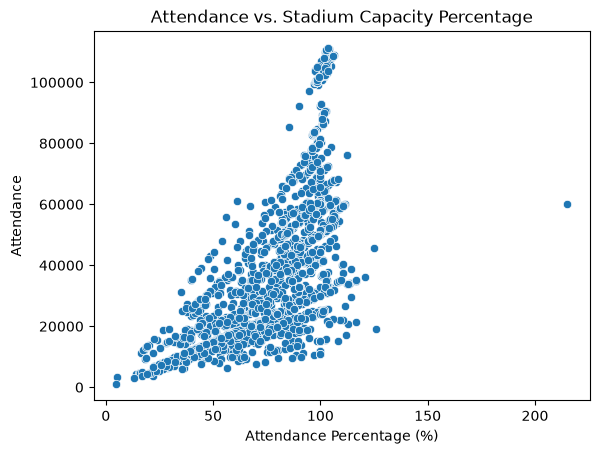

In [11]:
sns.scatterplot(data=df, x=df["attendance_pct"] * 100, y="attendance")
plt.title("Attendance vs. Stadium Capacity Percentage")
plt.xlabel("Attendance Percentage (%)")
plt.ylabel("Attendance")
plt.show()

The scatter plot shows a positive relationship between attendance percentage and total attendance. Most of the data points fall between 40% and 110%, showing that most stadiums have attendance at or near their listed capacity. As the attendance percentage increases, overall attendance also tends to increase. There are a few outliers above 100%, including one around 200%, meaning the recorded attendance was about twice the listed stadium capacity. Overall, the plot suggests that stadiums with higher attendance percentages generally have higher total attendance, although there is still some variation in the data.

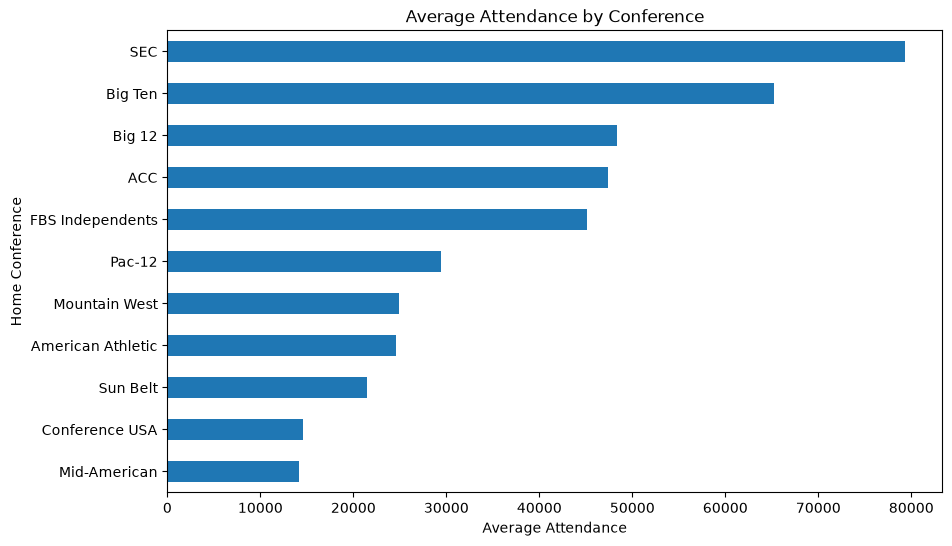

In [15]:
avg_conf_pct.sort_values().plot(kind="barh", figsize=(10, 6))
plt.title("Average Attendance by Conference")
plt.xlabel("Average Attendance")
plt.ylabel("Home Conference")
plt.show()

The bar chart shows that average attendance varies significantly across conferences. The SEC has the highest average attendance, at nearly 80,000 fans, followed by the Big Ten at around 65,000. The Big 12, ACC, and FBS Independents have similar average attendance levels, ranging from about 45,000 to 49,000. The Pac-12, Mountain West, American Athletic, Sun Belt, and Conference USA have lower average attendance, with Mid-American having the lowest at around 15,000. Overall, the chart shows a clear difference in average attendance among conferences, with the SEC and Big Ten having substantially higher attendance than the other conferences.

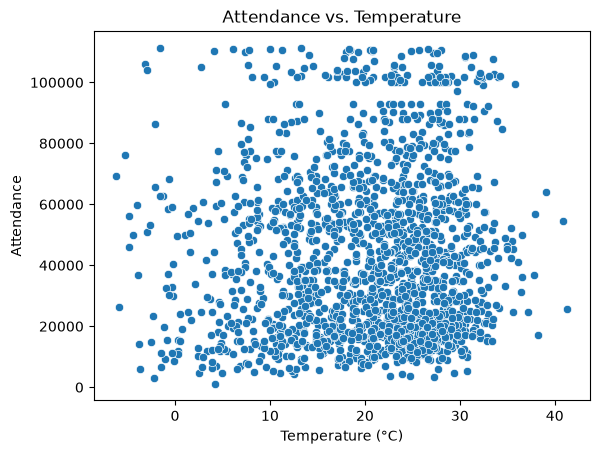

In [13]:
sns.scatterplot(data=df, x="temperature_c", y="attendance")
plt.title("Attendance vs. Temperature")
plt.xlabel("Temperature (°C)")
plt.ylabel("Attendance")
plt.show()

The scatter plot shows that there is not a strong relationship between temperature and attendance. Attendance varies widely across almost all temperatures, with many games having attendance between about 10,000 and 60,000 regardless of the temperature. There are also several high-attendance games above 80,000, and some of these occur across a broad range of temperatures. This suggests that temperature alone does not have a clear effect on attendance in this dataset. Overall, the points are widely scattered, indicating a weak correlation between temperature and attendance.

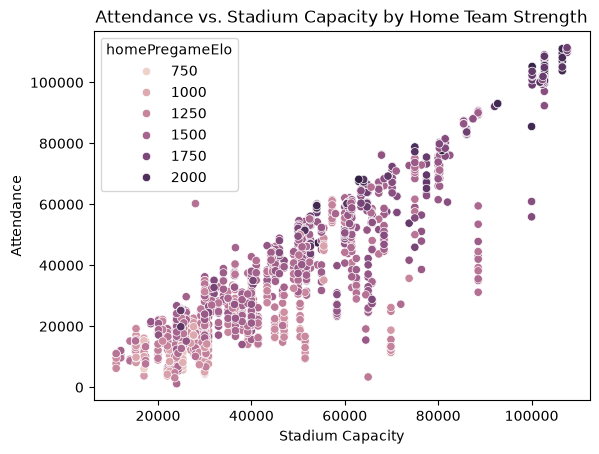

In [17]:
sns.scatterplot(
    data=df,
    x="capacity",
    y="attendance",
    hue="homePregameElo"
)
plt.title("Attendance vs. Stadium Capacity by Home Team Strength")
plt.xlabel("Stadium Capacity")
plt.ylabel("Attendance")
plt.show()

This scatter plot shows a strong positive relationship between stadium capacity and attendance, with attendance generally increasing as stadium capacity increases. The different shades represent home team strength using pregame Elo ratings. Higher-rated teams tend to appear more frequently among the higher-attendance games, especially in larger stadiums, suggesting that team strength may also be associated with higher attendance. However, there is still considerable variation, particularly among stadiums with capacities between about 50,000 and 80,000, where teams with different Elo ratings can have similar attendance levels. Overall, the graph suggests that stadium capacity is a major factor in attendance, while home team strength may provide additional insight into differences in attendance among games with similar stadium capacities.

## 3. Correlation Heatmap 

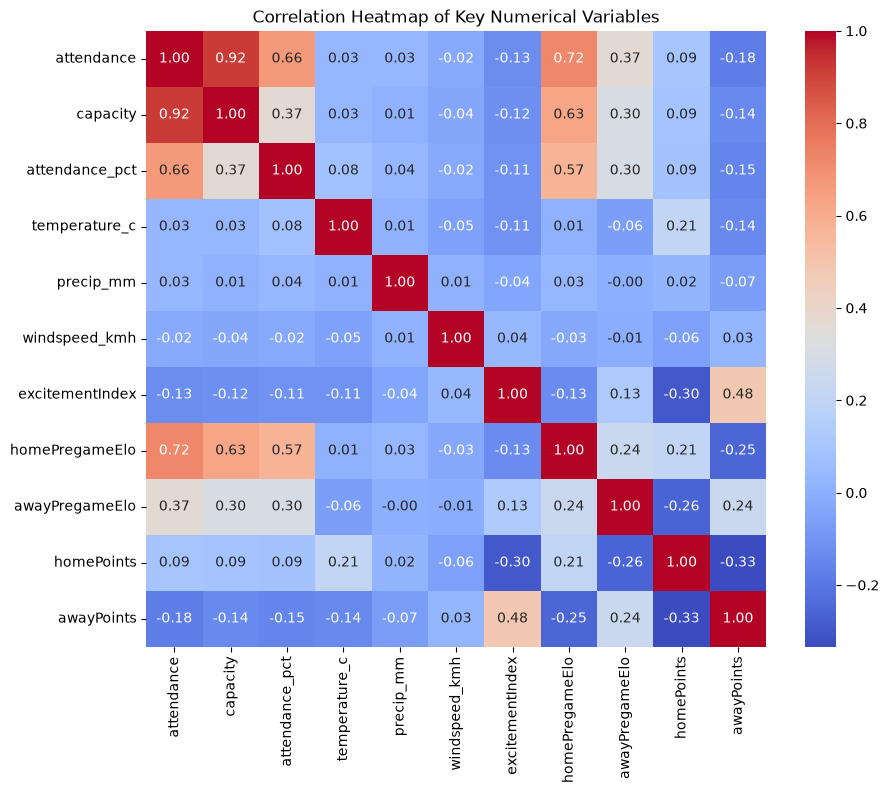

In [16]:
numeric_cols = [
    "attendance",
    "capacity",
    "attendance_pct",
    "temperature_c",
    "precip_mm",
    "windspeed_kmh",
    "excitementIndex",
    "homePregameElo",
    "awayPregameElo",
    "homePoints",
    "awayPoints"
]
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Key Numerical Variables")
plt.show()

The correlation heatmap shows the strength of the relationships between the numerical variables in the dataset. Stadium capacity has the strongest positive correlation with attendance (0.92), indicating that larger stadiums generally have much higher attendance. Home pregame Elo also has a relatively strong positive correlation with attendance (0.72), while attendance percentage has a moderate positive correlation (0.66). In comparison, temperature (0.03), precipitation (0.03), and wind speed (-0.03) have very weak correlations with attendance, suggesting that these weather factors have little linear relationship with attendance in this dataset. Overall, the heatmap suggests that stadium capacity and team strength are more strongly associated with attendance than weather conditions.